64
64


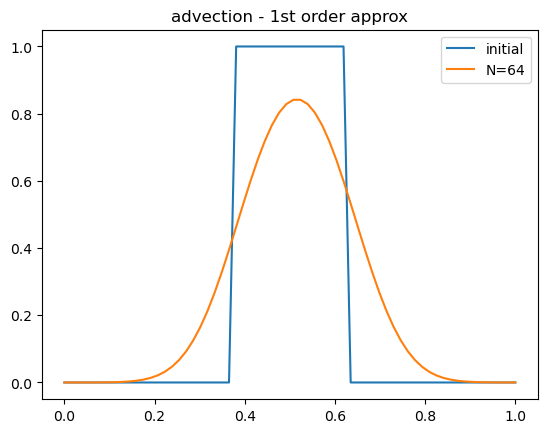

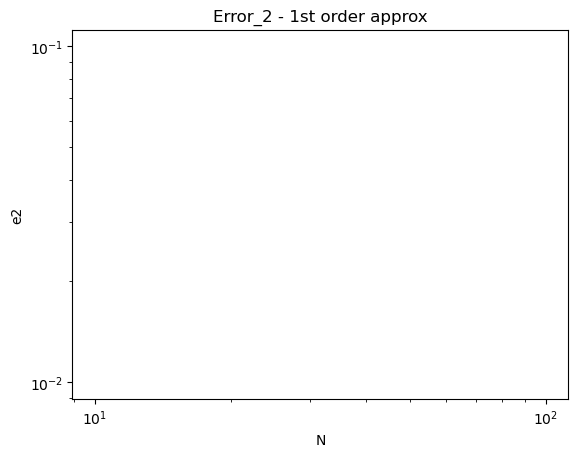

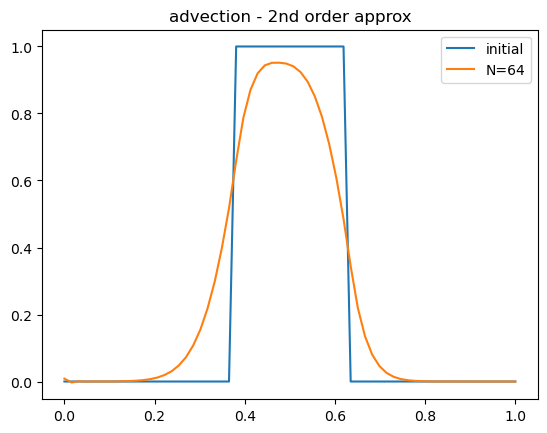

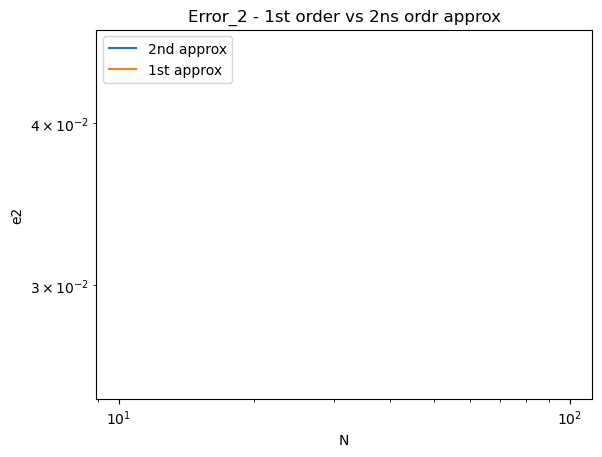

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import time



#%% Q3 - 1D finite volume

#%% first order: upwind - fix negative velocity
CFL = 0.5  #= u*dt/dx
N_list_a = [64]
u = 1 

plt.figure()
plt.title('advection - 1st order approx')

#initial wave
N = 64
x = np.linspace(0,1,N)
a_vec = np.concatenate((np.zeros(int(3*N/8)), np.ones(int(N/4)), np.zeros(int(3*N/8))))
plt.plot(x,a_vec, label = 'initial')

eps_all_a = []
for N in N_list_a:
    print(N)

    N1 = int(N/4); N2 = int((N-N1)/2 + 1)
    x = np.linspace(0,1,N)
    a_vec_0 = np.concatenate((np.zeros(N2), np.ones(N1), np.zeros(N2)))
    
    N_iterations = int(N/CFL)
    dx = x[1]-x[0]
    
    a_vec = a_vec_0
    
    for n in range(N_iterations):    
        a_vec[1] = a_vec[-2]
        a_vec[0] = a_vec[-3]
        a_vec[-1] = a_vec[2]
        a_vec_05 = a_vec   
            
        
        a_vec_new = a_vec*0
        
        for i in range(len(x)):
            a_vec_new[i+1] = a_vec[i+1] - CFL*(a_vec_05[i+1]-a_vec_05[i])
        
        a_vec = a_vec_new.copy()
    
    
    plt.plot(x, a_vec_new[1:-1], label = f"N={N}")
    
    eps_a = dx * np.sum((a_vec_new[1:-1]-a_vec_0[1:-1])**2)
    eps_all_a.append(eps_a)
plt.legend()    

plt.figure()  
plt.title('Error_2 - 1st order approx')
plt.plot(N_list_a, eps_all_a)
plt.xscale('log') 
plt.yscale('log') 
plt.xlabel('N')
plt.ylabel('e2')

#%% second order
def da_minmod(a_vec):
    a = a_vec[1:-1] - a_vec[:-2] 
    b = a_vec[2:] - a_vec[1:-1]
    m = np.zeros(len(a))
    
    true0 = (abs(a)<=abs(b))*(a*b>0) 
    true1 = (abs(a)>abs(b))*(a*b>0)
    true2 = (a*b<=0)
    m[true0] = a[true0] 
    m[true1] = b[true1]
    m[true2] = np.zeros(np.shape(m))[true2]
    
    # m = (a_vec[2:] - a_vec[:-2])/2
    return m

CFL = 0.5  #= u*dt/dx
# N_list = [128, 256, 512, 1024, 2048]
N_list = [64]
u = 1 

plt.figure()
plt.title('advection - 2nd order approx')

#initial wave
N = 64
x = np.linspace(0,1,N)
a_vec = np.concatenate((np.zeros(int(3*N/8)), np.ones(int(N/4)), np.zeros(int(3*N/8))))
plt.plot(x,a_vec, label = 'initial')

eps_all = []
for N in N_list:
    print(N)

    N1 = int(N/4); N2 = int((N-N1)/2 + 2)
    x = np.linspace(0,1,N)
    a_vec_0 = np.concatenate((np.zeros(N2), np.ones(N1), np.zeros(N2)))
    
    N_iterations = int((N-1)/CFL) 
    dx = x[1]-x[0]
    
    a_vec = a_vec_0
    
    for n in range(N_iterations): 
        
        da_vec = np.zeros(N+4); a_vec_L = np.zeros(N+4); F = np.zeros(N+4)      
        a_vec_new = np.zeros(N+4) 
        k1_udx = np.zeros(N+4); k2_udx = np.zeros(N+4)
           
        #periodicity:
        # a_vec[2] = a_vec[-3]
        # a_vec[0] = a_vec[-5] ; a_vec[1] = a_vec[-4]
        # a_vec[-1] = a_vec[3] ; a_vec[-2] = a_vec[4]   
        
        da_vec[1:-1] = da_minmod(a_vec)
        a_vec_L = a_vec + da_vec/2    
        F[1:] = a_vec_L[:-1]
        
        #runge-Kutta
        
        k1_udx[1:-1] = -(F[2:] - F[1:-1])
        a_vec_new[1:-1] = a_vec[1:-1] + CFL/2 * k1_udx[1:-1]
        
        a_vec_new[0] = a_vec_new[-4] ; a_vec_new[1] = a_vec_new[-3]
        a_vec_new[-1] = a_vec_new[2] ; a_vec_new[-2] = a_vec_new[3] 
        
        da_vec[1:-1] = da_minmod(a_vec_new)
        
        a_vec_L[1:-1] = a_vec_new[1:-1] + da_vec[1:-1]/2    
        F[1:] = a_vec_L[:-1]
        
        k2_udx[1:-1] = -(F[2:] - F[1:-1])       
        a_vec_new[1:-1] = a_vec[1:-1] + CFL * k2_udx[1:-1] 
        
        a_vec = a_vec_new.copy()
    
    plt.plot(x, a_vec_new[2:-2], label = f"N={N}")
    
    eps_a = dx * np.sum((a_vec_new[1:-1]-a_vec_0[1:-1])**2)
    eps_all.append(eps_a)
plt.legend()    

plt.figure()  
plt.title('Error_2 - 1st order vs 2ns ordr approx')
plt.plot(N_list, eps_all, label = '2nd approx')
plt.plot(N_list_a, eps_all_a, label = '1st approx')
plt.xscale('log') 
plt.yscale('log') 
plt.xlabel('N')
plt.ylabel('e2')
plt.legend()


